# imports

In [3]:
# !git clone https://github.com/moryacho/street-pattern-classifier.git

# !pip install huggingface_hub geopandas osmnx
# !pip install torch_geometric
# !pip install "folium>=0.12" matplotlib mapclassify

# !pip uninstall torch torchvision torchaudio -y
# !pip cache purge
# !pip install torch torchvision torchaudio

import torch

In [4]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import pandas as pd
import time
from tqdm import tqdm
import os
import networkx as nx
import json

import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
import warnings

from shapely.geometry import LineString, Polygon, Point
import shapely
import pickle
import ast



# data to train

## read data

In [5]:
big_gdf_all_polygons = gpd.read_file("data//gdf_data_polygons_85k.geojson")

In [4]:
big_gdf_all_polygons.head(2)

,Geography,Geographic Area Name,Estimate!!Total:,"Estimate!!Total:!!Car, truck, or van:","Estimate!!Total:!!Car, truck, or van:!!Drove alone","Estimate!!Total:!!Car, truck, or van:!!Carpooled:","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool",Estimate!!Total:!!Public transportation:,Estimate!!Total:!!Public transportation:!!Bus,Estimate!!Total:!!Public transportation:!!Subway or elevated rail,Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail,"Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)",Estimate!!Total:!!Public transportation:!!Ferryboat,Estimate!!Total:!!Bicycle,Estimate!!Total:!!Walked,"Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means",Estimate!!Total:!!Worked from home,geometry
0,1400000US01001020100,Census Tract 201; Autauga County; Alabama,803,787,691,96,96,0,0,0,0,0,0,0,0,0,0,0,16,"POLYGON ((-86.5091 32.47349, -86.50577 32.4757..."
1,1400000US01001020200,Census Tract 202; Autauga County; Alabama,977,763,762,1,1,0,0,0,0,0,0,0,0,0,5,0,209,"POLYGON ((-86.48122 32.47645, -86.48093 32.481..."


In [5]:
big_gdf_all_polygons.describe()

,Geography,Geographic Area Name,Estimate!!Total:,"Estimate!!Total:!!Car, truck, or van:","Estimate!!Total:!!Car, truck, or van:!!Drove alone","Estimate!!Total:!!Car, truck, or van:!!Carpooled:","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool",Estimate!!Total:!!Public transportation:,Estimate!!Total:!!Public transportation:!!Bus,Estimate!!Total:!!Public transportation:!!Subway or elevated rail,Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail,"Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)",Estimate!!Total:!!Public transportation:!!Ferryboat,Estimate!!Total:!!Bicycle,Estimate!!Total:!!Walked,"Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means",Estimate!!Total:!!Worked from home,geometry
count,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378,84378
unique,84378,84378,5232,4325,3964,997,795,431,403,1462,694,1194,414,222,189,351,962,455,1777,84378
top,1400000US72153750602,Census Tract 7506.02; Yauco Municipio; Puerto ...,1488,1444,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"POLYGON ((-86.64561 32.555532, -86.643596 32.5..."
freq,1,1,60,67,72,1898,3342,35214,45105,41114,47783,73020,74512,80354,82509,63956,26436,26777,1310,1


In [6]:
big_gdf_all_polygons = big_gdf_all_polygons.to_crs(big_gdf_all_polygons.estimate_utm_crs())

big_gdf_all_polygons["area"] = big_gdf_all_polygons.geometry.area
big_gdf_all_polygons = big_gdf_all_polygons.to_crs(4326)

In [7]:
big_gdf_all_polygons.area.describe()

C:\Users\yanaz\AppData\Local\Temp\ipykernel_15800\1656398169.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  big_gdf_all_polygons.area.describe()


count    84378.000000
mean         0.013030
std          0.255807
min          0.000002
25%          0.000180
50%          0.000485
75%          0.003087
max         51.035907
dtype: float64

In [8]:
percentile = big_gdf_all_polygons.area.quantile(0.9)
filtered_areas = big_gdf_all_polygons[big_gdf_all_polygons.area <= percentile]
filtered_areas.describe()

C:\Users\yanaz\AppData\Local\Temp\ipykernel_15800\1240995130.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  percentile = big_gdf_all_polygons.area.quantile(0.9)
C:\Users\yanaz\AppData\Local\Temp\ipykernel_15800\1240995130.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_areas = big_gdf_all_polygons[big_gdf_all_polygons.area <= percentile]


,area
count,7.594000e+04
mean,4.786138e+07
std,9.369354e+07
min,2.761833e+04
25%,3.727196e+06
50%,9.814742e+06
75%,3.850670e+07
max,1.003365e+09


In [10]:
filtered_areas.head(2)

,Geography,Geographic Area Name,Estimate!!Total:,"Estimate!!Total:!!Car, truck, or van:","Estimate!!Total:!!Car, truck, or van:!!Drove alone","Estimate!!Total:!!Car, truck, or van:!!Carpooled:","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool",Estimate!!Total:!!Public transportation:,...,Estimate!!Total:!!Public transportation:!!Subway or elevated rail,Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail,"Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)",Estimate!!Total:!!Public transportation:!!Ferryboat,Estimate!!Total:!!Bicycle,Estimate!!Total:!!Walked,"Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means",Estimate!!Total:!!Worked from home,geometry,area
0,1400000US01001020100,Census Tract 201; Autauga County; Alabama,803,787,691,96,96,0,0,0,...,0,0,0,0,0,0,0,16,"POLYGON ((-86.5091 32.47349, -86.50577 32.4757...",3.383432e+07
1,1400000US01001020200,Census Tract 202; Autauga County; Alabama,977,763,762,1,1,0,0,0,...,0,0,0,0,0,5,0,209,"POLYGON ((-86.48122 32.47645, -86.48093 32.481...",1.138010e+07


## geo place column

In [9]:
gdf_with_geo_place = filtered_areas.copy()

gdf_with_geo_place['geo_place'] = gdf_with_geo_place['Geographic Area Name'].str.split(';').str[1] + gdf_with_geo_place['Geographic Area Name'].str.split(';').str[2]

In [42]:
set(gdf_with_geo_place['geo_place'].to_list())

{' Montgomery County Texas',
 ' Jefferson Parish Louisiana',
 ' Vermilion County Illinois',
 ' Cass County Iowa',
 ' Freeborn County Minnesota',
 ' Sweetwater County Wyoming',
 ' Williamsburg County South Carolina',
 ' San Lorenzo Municipio Puerto Rico',
 ' Webster County Iowa',
 ' Muskingum County Ohio',
 ' Phillips County Arkansas',
 ' Minnehaha County South Dakota',
 ' Alexander County Illinois',
 ' St. Francis County Arkansas',
 ' Adams County Mississippi',
 ' Montrose County Colorado',
 ' Cherokee County Oklahoma',
 ' Richardson County Nebraska',
 ' Macon County Illinois',
 ' Washington County Iowa',
 ' Carroll County Georgia',
 ' Ellis County Kansas',
 ' Iron County Utah',
 ' DeSoto County Mississippi',
 ' Brazoria County Texas',
 ' Linn County Kansas',
 ' Asotin County Washington',
 ' Kenosha County Wisconsin',
 ' Montgomery County Kansas',
 ' Tunica County Mississippi',
 ' DeKalb County Tennessee',
 ' Burke County North Carolina',
 ' Faulkner County Arkansas',
 ' Norfolk city V

In [10]:
def convert_numpy_types(obj):
    if isinstance(obj, dict):
        return {key: convert_numpy_types(value) for key, value in obj.items()}
    elif isinstance(obj, (np.int_, np.intc, np.intp, np.int8,
                          np.int16, np.int32, np.int64, np.uint8,
                          np.uint16, np.uint32, np.uint64)):
        return int(obj)
    elif isinstance(obj, (np.float_, np.float16, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    elif isinstance(obj, (np.bool_)):
        return bool(obj)
    else:
        return obj

def save_dict_to_json(data_dict, filename='dictionary.json'):
    converted_dict = convert_numpy_types(data_dict)
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(converted_dict, f, ensure_ascii=False, indent=2)
    
    # print(f"✅ Словарь сохранен в {filename}")
    # print(f"   Количество элементов: {len(data_dict)}")

def load_dict_from_json(filename='dictionary.json'):

    with open(filename, 'r', encoding='utf-8') as f:
        data_dict = json.load(f)
    
    # print(f"✅ Словарь загружен из {filename}")
    # print(f"   Количество элементов: {len(data_dict)}")
    
    return data_dict

# save_dict_to_json(county_osm_dict, 'my_dict.json')
# county_osm_dict = load_dict_from_json('my_dict.json')

In [13]:
county_osm_dict = load_dict_from_json('my_dict.json')

In [14]:
len(county_osm_dict)

965

## graphs

In [11]:
def save_graphs_to_pickle(graph_dict, filename='graphs_dictionary.pkl'):

    with open(filename, 'wb') as f:
        pickle.dump(graph_dict, f)
    
    # print(f"✅ Словарь сохранен в {filename}")
    # print(f"   Количество графов: {len(graph_dict)}")
    # print(f"   Размер файла: {os.path.getsize(filename) / (1024*1024):.2f} MB")

def load_graphs_from_pickle(filename='graphs_dictionary.pkl'):

    with open(filename, 'rb') as f:
        graph_dict = pickle.load(f)
    
    # print(f"✅ Словарь загружен из {filename}")
    # print(f"   Количество графов: {len(graph_dict)}")
    
    return graph_dict

# save_graphs_to_pickle(my_graph_dict, 'my_graphs.pkl')
# loaded_dict = load_graphs_from_pickle('my_graphs.pkl')

In [12]:
def add_graph_column(gdf : gpd.GeoDataFrame, 
                      graphs_dict : dict, 
                      graph_column : str = "graph",
                      target_crs : int = 32631) -> gpd.GeoDataFrame:

    gdf_list = [group for _, group in gdf.groupby('geo_place')]
    gdf_list_drive_graph = []

    for gdf_geo_place in gdf_list:
        curr_geo_place = gdf_geo_place.iloc[0].geo_place
        if curr_geo_place not in graphs_dict:
            continue
        big_pt_g = nx.MultiDiGraph(graphs_dict[curr_geo_place])
        
        if big_pt_g.number_of_edges() == 0 and big_pt_g.number_of_nodes() == 0:
            continue
        
        g_crs = big_pt_g.graph["crs"] 
        gdf_geo_place_proj = gdf_geo_place.to_crs(g_crs)
        gdf_geo_place_proj[graph_column] = None
        
        # Работаем с графом в его родном CRS
        nodes_gdf, edges_gdf = ox.graph_to_gdfs(nx.MultiDiGraph(big_pt_g))
        
        # Пространственные операции теперь будут корректными
        nodes_in_polygons = gpd.sjoin(nodes_gdf, gdf_geo_place_proj[['geometry']], 
                                    how='inner', predicate='within')
        # gdf_geo_place_proj = gdf_geo_place.to_crs(g_crs)
        # gdf_geo_place_proj[graph_column] = None
        
        # nodes_gdf, edges_gdf = ox.graph_to_gdfs(nx.MultiDiGraph(big_pt_g))
        
        # nodes_in_polygons = gpd.sjoin(nodes_gdf, gdf_geo_place_proj[['geometry']], 
                                    # how='inner', predicate='within')
        nodes_by_polygon = nodes_in_polygons.groupby(nodes_in_polygons.index_right)
        
        new_nodes_to_add = {}
        
        for idx, row in gdf_geo_place_proj.iterrows():
            polygon_geom = row.geometry
            
            if idx in nodes_by_polygon.groups:
                polygon_nodes = nodes_by_polygon.get_group(idx)
                node_ids_inside = set(polygon_nodes.index)
            else:
                node_ids_inside = set()
            
            edges_to_add = []
            
            for u, v, key, data in big_pt_g.edges(keys=True, data=True):
                if u in node_ids_inside and v in node_ids_inside:
                    edges_to_add.append((u, v, key, data, 'full'))
                
                elif (u in node_ids_inside) != (v in node_ids_inside):  
                    if 'geometry' in data:
                        edge_geom = data['geometry']
                        
                        if edge_geom.intersects(polygon_geom):
                            intersection = edge_geom.intersection(polygon_geom)
                            
                            if not intersection.is_empty:
                                new_data = data.copy()
                                new_data['geometry'] = intersection
                                new_data['trimmed'] = True  
                                new_data['original_edge'] = (u, v, key)
                                
                                inside_node = u if u in node_ids_inside else v

                                if intersection.geom_type == 'LineString':
                                    boundary_point = intersection.coords[-1] if inside_node == u else intersection.coords[0]
                                elif intersection.geom_type == 'Point':
                                    boundary_point = intersection.coords[0]
                                else:
                                    continue
                                
                                boundary_node_id = f"boundary_{u}_{v}_{key}_{idx}"
                                
                                if boundary_node_id not in new_nodes_to_add and boundary_node_id not in big_pt_g.nodes:
                                    new_nodes_to_add[boundary_node_id] = {
                                        'x': boundary_point[0],
                                        'y': boundary_point[1],
                                        'boundary_node': True,
                                        'original_polygon': idx
                                    }
                                
                                if inside_node == u:
                                    edges_to_add.append((u, boundary_node_id, f"{key}_trimmed", new_data, 'trimmed'))
                                else:
                                    edges_to_add.append((boundary_node_id, v, f"{key}_trimmed", new_data, 'trimmed'))
                
                elif u not in node_ids_inside and v not in node_ids_inside:
                    if 'geometry' in data:
                        edge_geom = data['geometry']
                        
                        if edge_geom.intersects(polygon_geom):
                            intersection = edge_geom.intersection(polygon_geom)
                            
                            if not intersection.is_empty and intersection.geom_type == 'LineString':
                                coords = list(intersection.coords)
                                
                                if len(coords) >= 2:
                                    node_in_id = f"boundary_in_{u}_{v}_{key}_{idx}"
                                    node_out_id = f"boundary_out_{u}_{v}_{key}_{idx}"
                                    
                                    for node_id, point in [(node_in_id, coords[0]), (node_out_id, coords[-1])]:
                                        if node_id not in new_nodes_to_add and node_id not in big_pt_g.nodes:
                                            new_nodes_to_add[node_id] = {
                                                'x': point[0],
                                                'y': point[1],
                                                'boundary_node': True,
                                                'original_polygon': idx
                                            }
                                    
                                    new_data = data.copy()
                                    new_data['geometry'] = intersection
                                    new_data['trimmed'] = True
                                    new_data['original_edge'] = (u, v, key)
                                    
                                    edges_to_add.append((node_in_id, node_out_id, f"{key}_through", new_data, 'through'))
            
            if len(node_ids_inside) > 0 or len(edges_to_add) > 0:
                subgraph = nx.MultiDiGraph()
                subgraph.graph['crs'] = g_crs 
                subgraph.graph['parent_polygon'] = curr_geo_place
                
                for node_id in node_ids_inside:
                    node_data = big_pt_g.nodes[node_id]
                    subgraph.add_node(node_id, **node_data)
                
                for node_id, node_data in new_nodes_to_add.items():
                    if node_data.get('original_polygon') == idx:
                        subgraph.add_node(node_id, **node_data)
                
                for u, v, key, data, edge_type in edges_to_add:
                    subgraph.add_edge(u, v, key=key, **data)
                
                gdf_geo_place_proj.at[idx, graph_column] = subgraph
        
        # gdf_final = gdf_geo_place_proj.to_crs(target_crs)
        gdf_final = gdf_geo_place_proj.to_crs(f"EPSG:{target_crs}")
        
        # for idx, row in gdf_final.iterrows():
        #     if row[graph_column] is not None:
        #         row[graph_column].graph['crs'] = str(target_crs)
        
        # gdf_list_drive_graph.append(gdf_final)
        for idx, row in gdf_final.iterrows():
            if row[graph_column] is not None:
                row[graph_column].graph['crs'] = f"EPSG:{target_crs}"
        
        gdf_list_drive_graph.append(gdf_final)
    
    # if gdf_list_drive_graph:
    #     return gpd.GeoDataFrame(pd.concat(gdf_list_drive_graph, ignore_index=True), geometry='geometry')
    # else:
    #     return gdf.iloc[0:0]

    if gdf_list_drive_graph:
        return gpd.GeoDataFrame(pd.concat(gdf_list_drive_graph, ignore_index=True), 
                                geometry='geometry', crs=f"EPSG:{target_crs}")
    else:
        return gdf.iloc[0:0]

In [13]:
import os

folder_path = 'drive_graphs_by_county//'

files = [folder_path + f for f in os.listdir(folder_path) 
         if os.path.isfile(os.path.join(folder_path, f))]


In [ ]:
geo_places_list = list(gdf['geo_place'].unique())
no_in_list = 0
in_list = 0
for file_path in tqdm(files):
    curr_geo_dict = load_graphs_from_pickle(filename=file_path)
    if list(curr_geo_dict.keys())[0] not in geo_places_list:
        no_in_list += 1
    else:
        in_list += 1

print(no_in_list)
print(in_list)

100%|██████████| 978/978 [02:35<00:00,  6.30it/s]


In [ ]:
gdf = gdf_with_geo_place.copy()
all_results = []
list_processed_geo_places = [f for f in os.listdir('drive_graphs_by_county_with_data//') 
         if os.path.isfile(os.path.join('drive_graphs_by_county_with_data//', f))]


for geo_place_dict_path in tqdm(files):
    curr_file_name = geo_place_dict_path.split("//")[1]
    if curr_file_name in list_processed_geo_places:
        # print(f"{curr_file_name} already processed")
        continue
    curr_geo_dict = load_graphs_from_pickle(filename=geo_place_dict_path)
    dict_geo_place = list(curr_geo_dict.keys())[0]
    
    mask = gdf['geo_place'] == dict_geo_place
    
    if mask.any():
        subset = gdf[mask].copy()

        result = add_graph_column(subset, curr_geo_dict, target_crs=4326, graph_column="drive_graph")
        if len(result) > 0:
            result.to_pickle(f"drive_graphs_by_county_with_data//{dict_geo_place.replace(' ', '_')[1::]}.pkl")
            list_processed_geo_places += [curr_file_name]

    # else:
        # print(f"geo_place {dict_geo_place} не найден в gdf")

 19%|█▉        | 184/978 [00:23<00:09, 86.93it/s]

In [ ]:
gdf_with_geo_place

## classify

In [43]:
list_processed_geo_places_gdf = ['drive_graphs_by_county_with_data//' + f for f in os.listdir('drive_graphs_by_county_with_data//') 
         if os.path.isfile(os.path.join('drive_graphs_by_county_with_data//', f))]

gdf_list = []
target_crs = 4326
for gdf_path in tqdm(list_processed_geo_places_gdf):
    curr_gdf = gpd.GeoDataFrame(pd.read_pickle(gdf_path), geometry="geometry")
    curr_gdf = curr_gdf.to_crs(target_crs)
    gdf_list += [curr_gdf]

if len(gdf_list) > 0:
    final_gdf = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True), geometry="geometry", crs=target_crs)


100%|██████████| 165/165 [00:31<00:00,  5.17it/s]


In [ ]:
final_gdf.to_pickle("drive_graphs_by_county_with_data//final_gdf.pkl")
final_gdf = gpd.GeoDataFrame(pd.read_pickle("drive_graphs_by_county_with_data//final_gdf.pkl"), geometry="geometry")

In [27]:
final_gdf.drive_graph.iloc[0].graph["crs"]

'EPSG:4326'

In [16]:
from huggingface_hub import hf_hub_download
import torch

model_path = hf_hub_download(
    repo_id="nochka/street-pattern-classifier",
    filename="best_model.pth",
    local_dir="./models"
)

d:\выбирай итмо и не  выбирай вообще\urban\corr_transport_street_pattern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
def get_subgraphs_dict(gdf : gpd.GeoDataFrame,
                       graph_column : str = "graph"):
    subgraphs = {}
    for idx, row in gdf.iterrows():
        if row[graph_column] is not None and row[graph_column].number_of_edges() != 0:
            g = row[graph_column]
            G_copy = g.copy()
            all_geoms = []
            for u, v, key, data in G_copy.edges(keys=True, data=True):
                if 'geometry' not in data:
                    if ('x' in G_copy.nodes[u] and 'y' in G_copy.nodes[u] and 
                    'x' in G_copy.nodes[v] and 'y' in G_copy.nodes[v]):
                    
                        line = LineString([
                            (G_copy.nodes[u]['x'], G_copy.nodes[u]['y']),
                            (G_copy.nodes[v]['x'], G_copy.nodes[v]['y'])
                        ])
                        G_copy.edges[u, v, key]['geometry'] = line
                    else:
                        print('не получилось добавить геометрию ребра')
                else:
                    line = data['geometry']
                all_geoms.append(line)
            
            if all_geoms:
                all_geoms_union = shapely.union_all(all_geoms)
                bbox_geom = shapely.box(*all_geoms_union.bounds)

            subgraphs[idx] = {
                'graph': G_copy,
                # 'polygon': row['geometry']
                'polygon': bbox_geom
            }
    return subgraphs


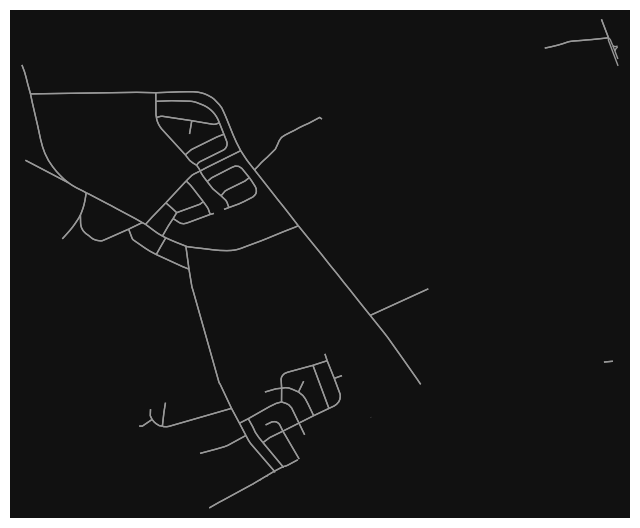

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [41]:
ox.plot_graph(final_gdf_utm.drive_graph.iloc[13])

In [45]:
import osmnx as ox

final_gdf_utm = final_gdf.to_crs(final_gdf.estimate_utm_crs())

for idx, row in final_gdf_utm.iterrows():
    if row['drive_graph'] is not None:
        final_gdf_utm.at[idx, 'drive_graph'] = ox.projection.project_graph(
            row['drive_graph'], 
            to_crs=final_gdf_utm.crs
        )

subgraphs = get_subgraphs_dict(final_gdf_utm, "drive_graph")

In [46]:
len(subgraphs)

4473

In [31]:
import sys
sys.path.insert(0, './street-pattern-classifier')

from block_dataset import BlockDataset
dataset = BlockDataset(subgraphs)

Computing features for all subgraphs...


Processing subgraphs...:   3%|▎         | 104/3025 [13:02<6:06:10,  7.52s/it]


KeyboardInterrupt: 

In [ ]:
# torch.save(dataset, 'block_dataset_10k.pt')

# loaded_dataset = torch.load('block_dataset.pt')

In [ ]:
from classification import classify_blocks
predictions_blocks, probabilities_blocks = classify_blocks(
    dataset,
    model_path=model_path,
    device='cpu'
)

In [ ]:
def add_predictions_to_gdf(gdf, predictions_blocks, probabilities_blocks) -> gpd.GeoDataFrame:

    gdf_with_predictions = gdf.copy()
    gdf_with_predictions['prediction'] = None
    
    num_classes = len(next(iter(probabilities_blocks.values()))) if probabilities_blocks else 7
    for i in range(num_classes):
        gdf_with_predictions[f'prob_{i}'] = None
    
    for idx in gdf_with_predictions.index:
        if idx in predictions_blocks:
            gdf_with_predictions.at[idx, 'prediction'] = predictions_blocks[idx]
            
            if idx in probabilities_blocks:
                probs = probabilities_blocks[idx]
                for i, prob in enumerate(probs):
                    gdf_with_predictions.at[idx, f'prob_{i}'] = prob
    
    return gdf_with_predictions


In [ ]:
gdf_with_predictions = add_predictions_to_gdf(
    final_gdf, 
    predictions_blocks, 
    probabilities_blocks
)


print(gdf_with_predictions['prediction'].value_counts().sort_index())


# predictor